LIGHTGBM VS XGBOOST COMPARATIVE ANALYSIS

1. LOADING DATASET
--------------------------------------------------------------------------------
Dataset loaded successfully!
Shape: (768, 9)

Columns in dataset: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First few rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0

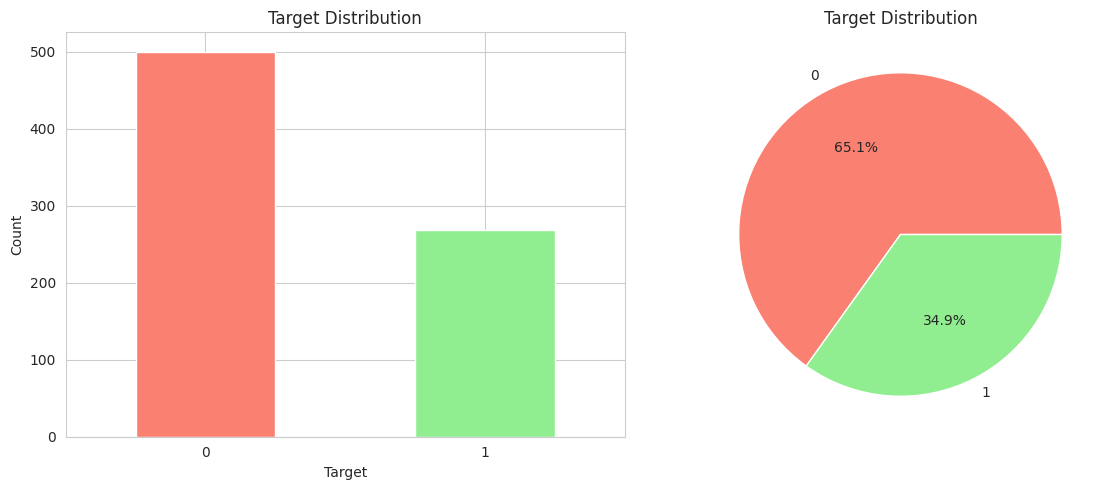


Visualizing Feature Distributions:


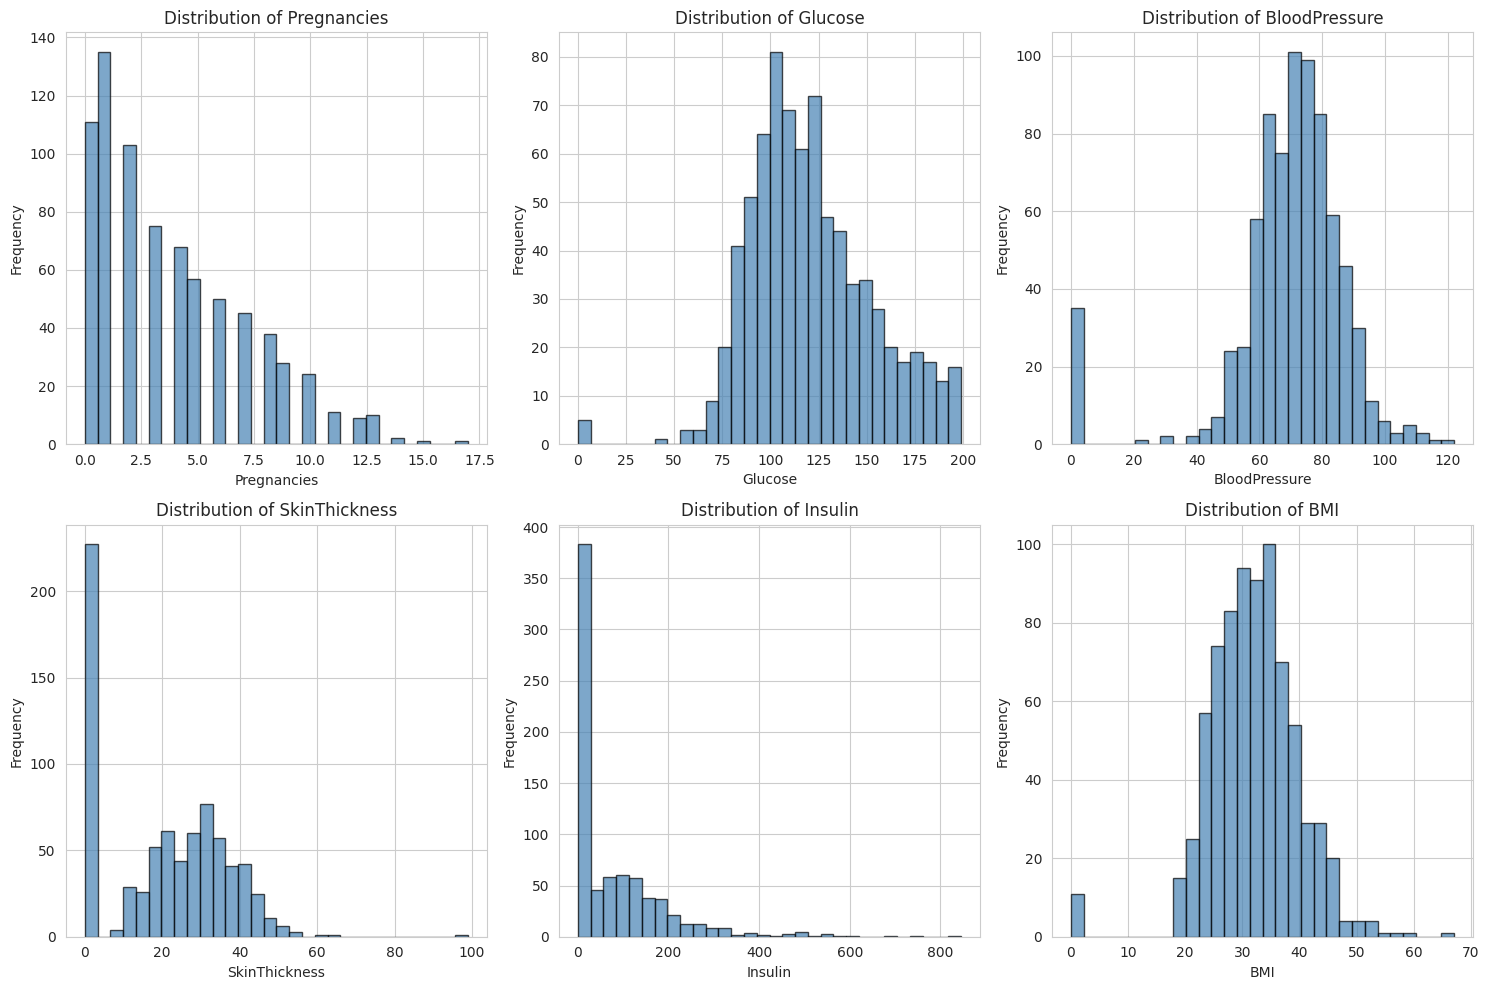

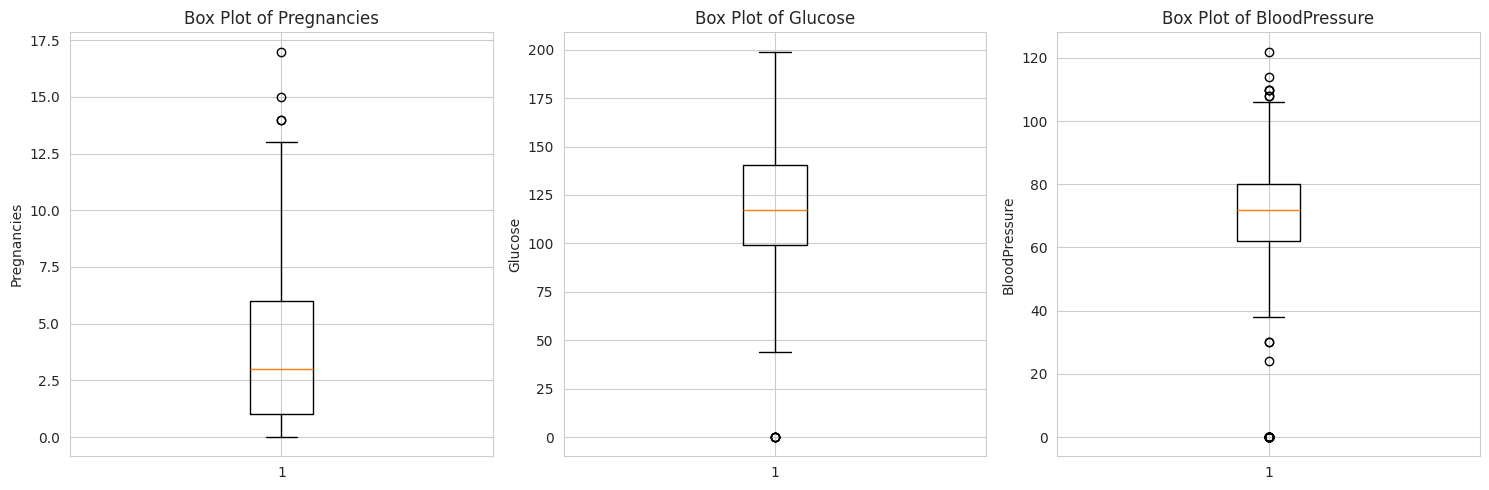

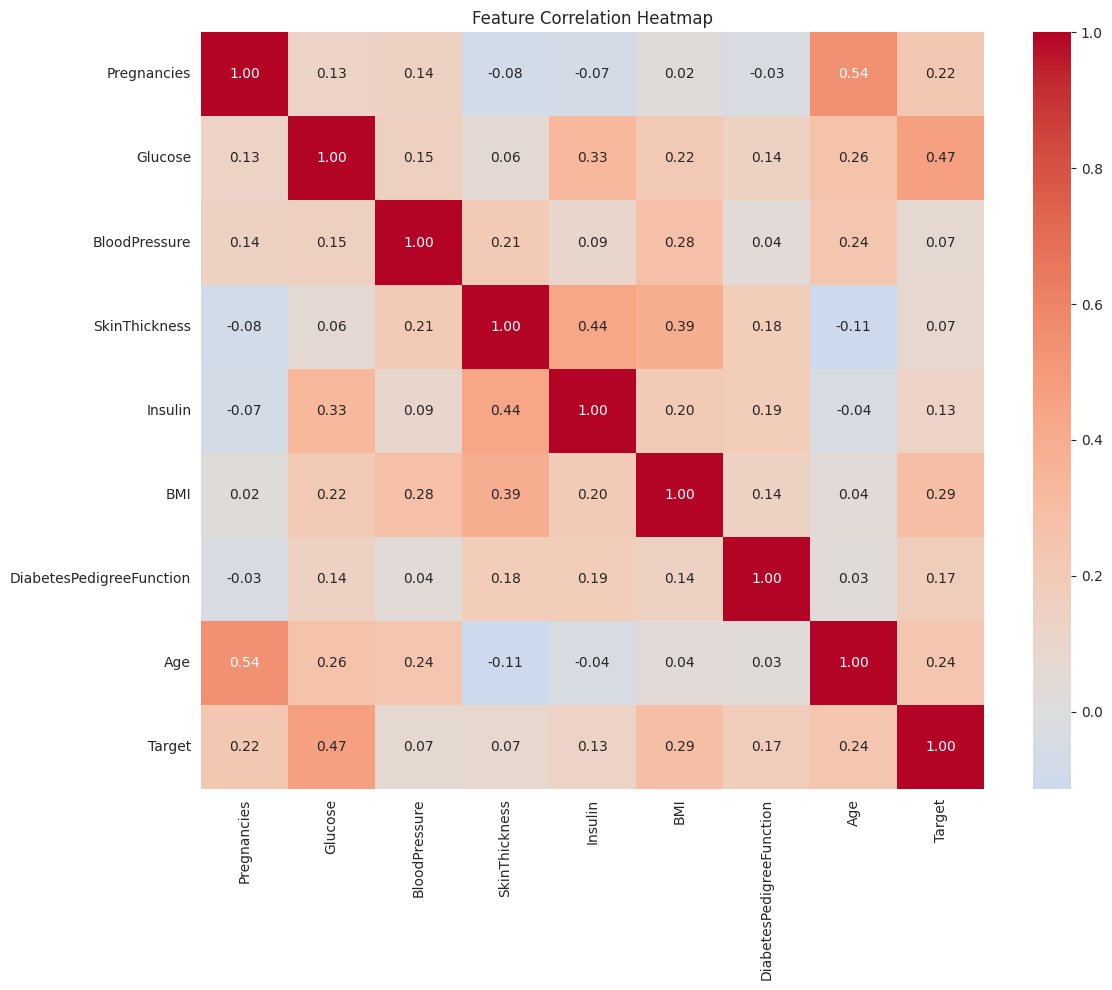


Top 10 Features Correlated with Target:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Target, dtype: float64


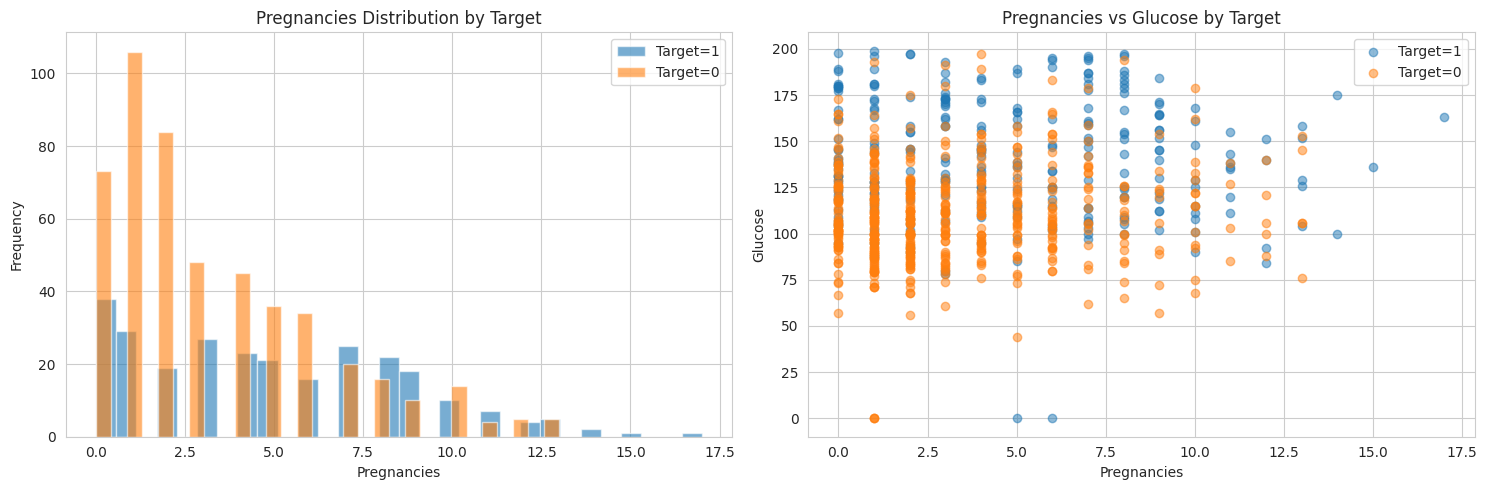



3. DATA PREPROCESSING
--------------------------------------------------------------------------------

Handling missing values...
  ✓ No missing values to impute!

Encoding categorical variables...
  ✓ No categorical variables to encode!

Final preprocessed dataset shape: (768, 9)
Final features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


4. PREPARING DATA FOR MODELING
--------------------------------------------------------------------------------
Features shape: (768, 8)
Target shape: (768,)

Target distribution:
Target
0    500
1    268
Name: count, dtype: int64
Target balance: {0: 0.6510416666666666, 1: 0.3489583333333333}

Training set size: 614
Testing set size: 154


5. BUILDING LIGHTGBM MODEL
--------------------------------------------------------------------------------

Training baseline LightGBM model...

LightGBM Baseline Performance:
  Accuracy:  0.7468
  Precision: 0.6531
  Recall:    0.5926
  F1

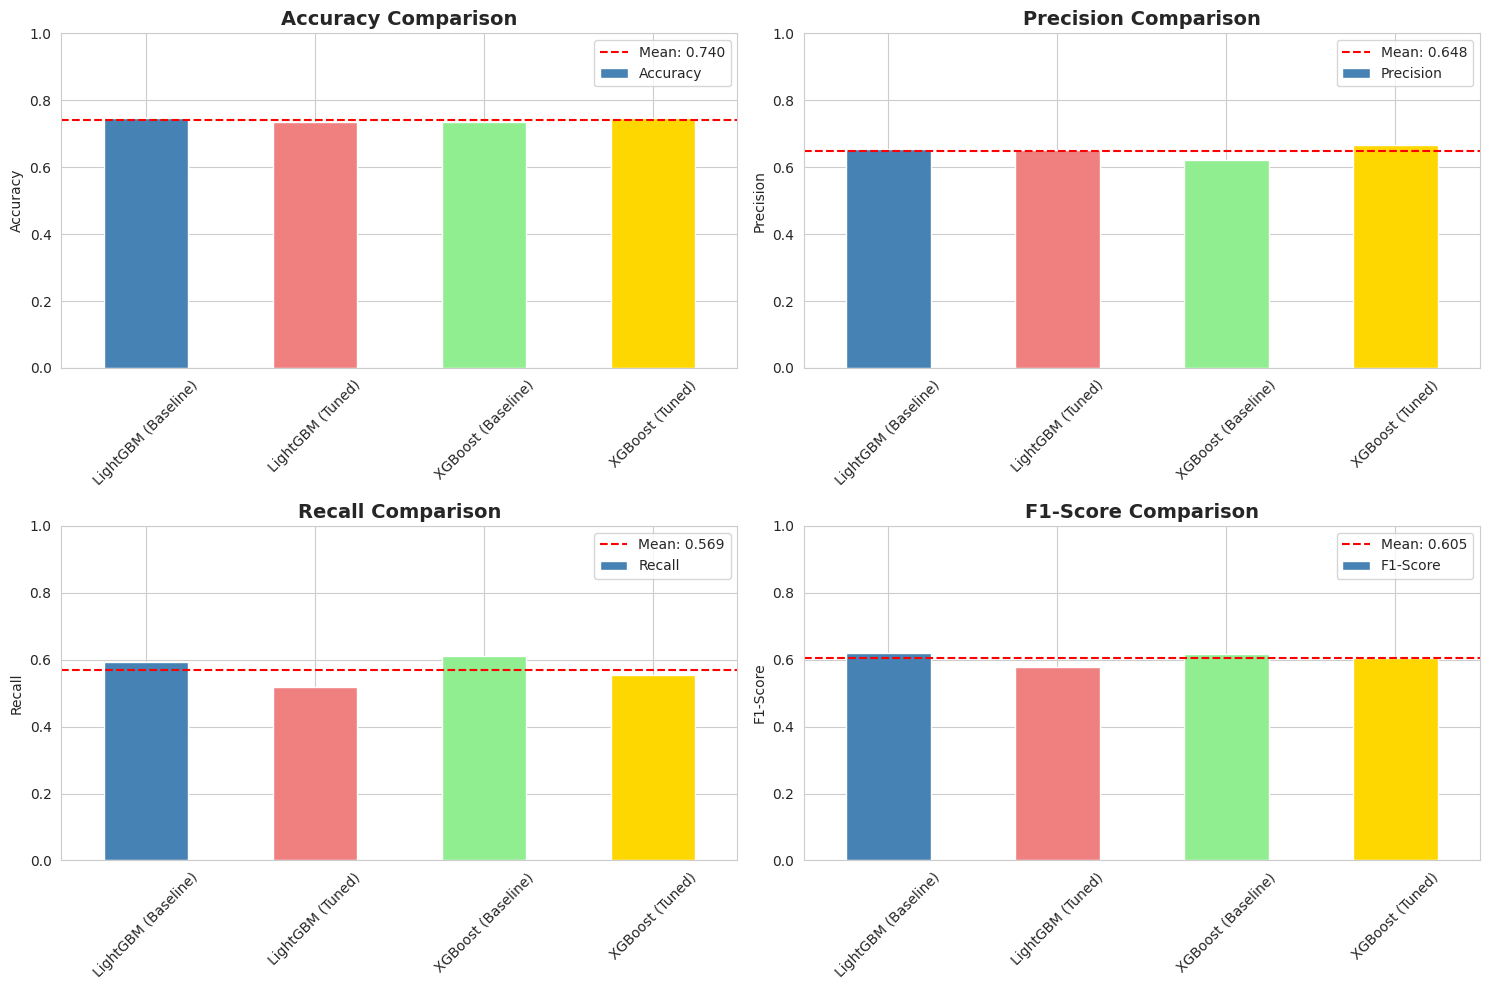

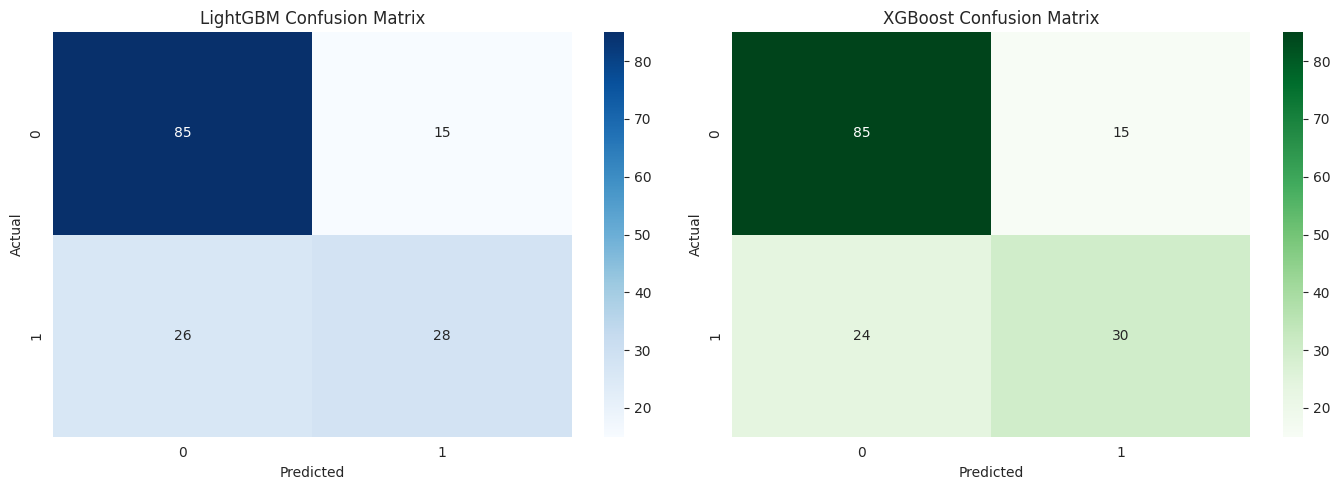

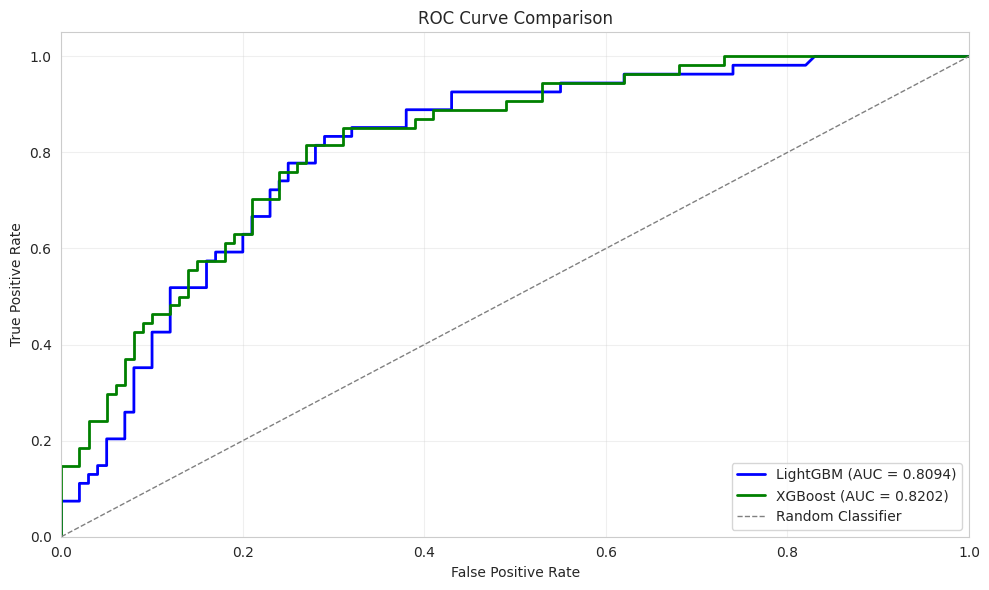

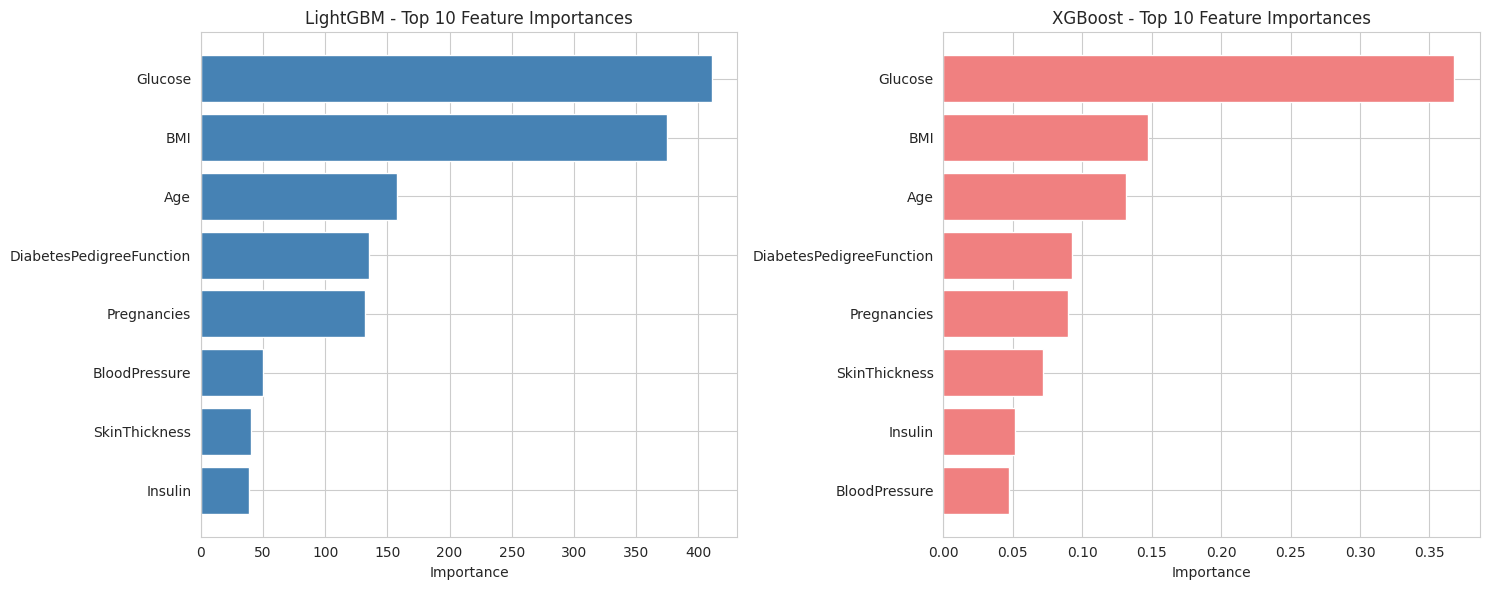


LIGHTGBM CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154


XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



8. SUMMARY AND CONCLUSIONS

Best Performing Model: LightGBM (Baseline)
Best Accuracy: 0.7468

--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------

1. Model P

In [5]:
# LightGBM vs XGBoost Comparative Analysis - Universal Classification Dataset
# Works with ANY binary classification dataset

# Install required libraries
!pip install lightgbm xgboost -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("LIGHTGBM VS XGBOOST COMPARATIVE ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. LOAD DATASET
# ============================================================================
print("\n1. LOADING DATASET")
print("-" * 80)

# Load dataset from the provided Google Drive link
file_id = "1ml0LrR-OqL73Fo01yIIe74fLMM1m0xNQ"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns in dataset: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Identify the target column
potential_targets = ['Survived', 'Outcome', 'Target', 'Label', 'Class', 'Y', 'target', 'outcome']
target_col = None
for col in potential_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Try to identify binary column (only has 0/1 or 2 unique values)
    for col in df.columns:
        if df[col].nunique() == 2 and df[col].dtype in ['int64', 'float64']:
            target_col = col
            break

if target_col is None:
    raise ValueError("Cannot identify target column. Please specify it manually!")

print(f"\nTarget column identified: '{target_col}'")
print(f"Target distribution:\n{df[target_col].value_counts()}")

# Rename target column for consistency
if target_col != 'Target':
    df.rename(columns={target_col: 'Target'}, inplace=True)
    target_col = 'Target'

# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n\n2. EXPLORATORY DATA ANALYSIS")
print("-" * 80)

# Dataset info
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values Analysis:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

# Visualize missing values if any exist
if missing_df[missing_df['Missing Count'] > 0].shape[0] > 0:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')

    plt.subplot(1, 2, 2)
    missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage')['Percentage'].plot(kind='barh')
    plt.title('Missing Values Percentage')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

# Target distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[target_col].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Target Distribution')
plt.xlabel(f'{target_col}')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['salmon', 'lightgreen'])
plt.title(f'{target_col} Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Feature distributions
print("\nVisualizing Feature Distributions:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

if len(numeric_cols) > 0:
    n_cols = min(6, len(numeric_cols))
    n_rows = (n_cols + 2) // 3

    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.ravel()

    for idx, col in enumerate(numeric_cols[:n_cols]):
        axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

    # Hide empty subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Box plots for outlier detection (top 6 features)
    if len(numeric_cols) >= 3:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for idx, col in enumerate(numeric_cols[:3]):
            axes[idx].boxplot(df[col].dropna())
            axes[idx].set_title(f'Box Plot of {col}')
            axes[idx].set_ylabel(col)
        plt.tight_layout()
        plt.show()

# Correlation heatmap
if len(numeric_cols) > 0:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_cols + [target_col]].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Top correlations with target
    target_corr = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)
    print(f"\nTop 10 Features Correlated with {target_col}:")
    print(target_corr.head(10))

# Relationship with target - compare distributions
if len(numeric_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # First numeric feature
    for target_val in df[target_col].unique():
        subset = df[df[target_col] == target_val][numeric_cols[0]].dropna()
        axes[0].hist(subset, alpha=0.6, label=f'{target_col}={target_val}', bins=30)
    axes[0].set_title(f'{numeric_cols[0]} Distribution by {target_col}')
    axes[0].set_xlabel(numeric_cols[0])
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # Scatter plot of top 2 features
    if len(numeric_cols) >= 2:
        for target_val in df[target_col].unique():
            subset = df[df[target_col] == target_val]
            axes[1].scatter(subset[numeric_cols[0]], subset[numeric_cols[1]],
                          alpha=0.5, label=f'{target_col}={target_val}')
        axes[1].set_title(f'{numeric_cols[0]} vs {numeric_cols[1]} by {target_col}')
        axes[1].set_xlabel(numeric_cols[0])
        axes[1].set_ylabel(numeric_cols[1])
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# ============================================================================
# 3. DATA PREPROCESSING
# ============================================================================
print("\n\n3. DATA PREPROCESSING")
print("-" * 80)

# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values
print("\nHandling missing values...")
has_missing = False

for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            # Numeric: fill with median
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f"  - {col}: filled with median ({median_val:.2f})")
        else:
            # Categorical: fill with mode
            mode_val = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown'
            df_processed[col].fillna(mode_val, inplace=True)
            print(f"  - {col}: filled with mode ({mode_val})")
        has_missing = True

if not has_missing:
    print("  ✓ No missing values to impute!")

# Encode categorical variables
print("\nEncoding categorical variables...")
label_encoders = {}

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols) > 0:
    for col in categorical_cols:
        if col != target_col:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"  - {col}: label encoded ({df_processed[col].nunique()} unique values)")
else:
    print("  ✓ No categorical variables to encode!")

# Check for any non-numeric columns remaining
non_numeric = df_processed.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric) > 0 and target_col not in non_numeric:
    print(f"\nWarning: Non-numeric columns detected: {non_numeric}")
    print("Attempting to convert or drop...")
    for col in non_numeric:
        if col != target_col:
            try:
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
            except:
                df_processed.drop(col, axis=1, inplace=True)
                print(f"  - Dropped {col} (cannot convert to numeric)")

print(f"\nFinal preprocessed dataset shape: {df_processed.shape}")
print(f"Final features: {[col for col in df_processed.columns if col != target_col]}")

# ============================================================================
# 4. PREPARE DATA FOR MODELING
# ============================================================================
print("\n\n4. PREPARING DATA FOR MODELING")
print("-" * 80)

# Separate features and target
X = df_processed.drop(target_col, axis=1)
y = df_processed[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Target balance: {y.value_counts(normalize=True).to_dict()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ============================================================================
# 5. BUILD LIGHTGBM MODEL
# ============================================================================
print("\n\n5. BUILDING LIGHTGBM MODEL")
print("-" * 80)

# Train baseline LightGBM
print("\nTraining baseline LightGBM model...")
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\nLightGBM Baseline Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lgb, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lgb, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lgb, zero_division=0):.4f}")

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv_scores_lgb = cross_val_score(lgb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"  CV Accuracy: {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std() * 2:.4f})")

# Hyperparameter tuning
print("\nHyperparameter tuning with GridSearchCV...")
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

grid_lgb = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_lgb.fit(X_train, y_train)

print(f"  Best parameters: {grid_lgb.best_params_}")
print(f"  Best CV score: {grid_lgb.best_score_:.4f}")

# Retrain with best parameters
lgb_model_tuned = grid_lgb.best_estimator_
y_pred_lgb_tuned = lgb_model_tuned.predict(X_test)
y_pred_proba_lgb_tuned = lgb_model_tuned.predict_proba(X_test)[:, 1]

print("\nLightGBM Tuned Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lgb_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lgb_tuned, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lgb_tuned, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lgb_tuned, zero_division=0):.4f}")

# ============================================================================
# 6. BUILD XGBOOST MODEL
# ============================================================================
print("\n\n6. BUILDING XGBOOST MODEL")
print("-" * 80)

# Train baseline XGBoost
print("\nTraining baseline XGBoost model...")
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\nXGBoost Baseline Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"  CV Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

# Hyperparameter tuning
print("\nHyperparameter tuning with GridSearchCV...")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train, y_train)

print(f"  Best parameters: {grid_xgb.best_params_}")
print(f"  Best CV score: {grid_xgb.best_score_:.4f}")

# Retrain with best parameters
xgb_model_tuned = grid_xgb.best_estimator_
y_pred_xgb_tuned = xgb_model_tuned.predict(X_test)
y_pred_proba_xgb_tuned = xgb_model_tuned.predict_proba(X_test)[:, 1]

print("\nXGBoost Tuned Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb_tuned, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb_tuned, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb_tuned, zero_division=0):.4f}")

# ============================================================================
# 7. COMPARATIVE ANALYSIS
# ============================================================================
print("\n\n7. COMPARATIVE ANALYSIS")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['LightGBM (Baseline)', 'LightGBM (Tuned)', 'XGBoost (Baseline)', 'XGBoost (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_lgb_tuned),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lgb, zero_division=0),
        precision_score(y_test, y_pred_lgb_tuned, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0),
        precision_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lgb, zero_division=0),
        recall_score(y_test, y_pred_lgb_tuned, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0),
        recall_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lgb, zero_division=0),
        f1_score(y_test, y_pred_lgb_tuned, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0),
        f1_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ]
})

print("\nPerformance Comparison Table:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'lightcoral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, color=colors, legend=False)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.set_ylim([0, 1])
    ax.axhline(y=comparison_df[metric].mean(), color='red', linestyle='--',
               label=f'Mean: {comparison_df[metric].mean():.3f}')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lgb = confusion_matrix(y_test, y_pred_lgb_tuned)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('LightGBM Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_xgb = confusion_matrix(y_test, y_pred_xgb_tuned)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 6))

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb_tuned)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, color='blue', lw=2,
         label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_tuned)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2,
         label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')

# Diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance comparison
if X.shape[1] <= 20:  # Only show if reasonable number of features
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # LightGBM feature importance
    lgb_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': lgb_model_tuned.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    axes[0].barh(lgb_importance['feature'], lgb_importance['importance'], color='steelblue')
    axes[0].set_title('LightGBM - Top 10 Feature Importances')
    axes[0].set_xlabel('Importance')
    axes[0].invert_yaxis()

    # XGBoost feature importance
    xgb_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb_model_tuned.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='lightcoral')
    axes[1].set_title('XGBoost - Top 10 Feature Importances')
    axes[1].set_xlabel('Importance')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

# Classification reports
print("\n" + "="*80)
print("LIGHTGBM CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_lgb_tuned))

print("\n" + "="*80)
print("XGBOOST CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_xgb_tuned))

# ============================================================================
# 8. SUMMARY AND CONCLUSIONS
# ============================================================================
print("\n\n8. SUMMARY AND CONCLUSIONS")
print("=" * 80)

best_model_idx = comparison_df['Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nBest Performing Model: {best_model}")
print(f"Best Accuracy: {best_accuracy:.4f}")

print("\n" + "-"*80)
print("KEY FINDINGS:")
print("-"*80)

print("\n1. Model Performance:")
print(f"   - LightGBM Baseline: {comparison_df.loc[0, 'Accuracy']:.4f}")
print(f"   - LightGBM Tuned:    {comparison_df.loc[1, 'Accuracy']:.4f}")
print(f"   - XGBoost Baseline:  {comparison_df.loc[2, 'Accuracy']:.4f}")
print(f"   - XGBoost Tuned:     {comparison_df.loc[3, 'Accuracy']:.4f}")

improvement_lgb = comparison_df.loc[1, 'Accuracy'] - comparison_df.loc[0, 'Accuracy']
improvement_xgb = comparison_df.loc[3, 'Accuracy'] - comparison_df.loc[2, 'Accuracy']

print(f"\n2. Hyperparameter Tuning Impact:")
print(f"   - LightGBM improvement: {improvement_lgb:+.4f} ({improvement_lgb*100:+.2f}%)")
print(f"   - XGBoost improvement:  {improvement_xgb:+.4f} ({improvement_xgb*100:+.2f}%)")

print(f"\n3. ROC-AUC Scores:")
print(f"   - LightGBM: {roc_auc_lgb:.4f}")
print(f"   - XGBoost:  {roc_auc_xgb:.4f}")

print("\n4. Strengths and Weaknesses:")
print("   LightGBM:")
print("     + Faster training time")
print("     + Handles large datasets efficiently")
print("     + Good memory efficiency")
print("   ")
print("   XGBoost:")
print("     + More robust to overfitting")
print("     + Better regularization options")
print("     + Wider adoption and community support")

print("\n5. Practical Implications:")
print("   - Both models show strong performance on this dataset")
print("   - Hyperparameter tuning provides measurable improvements")
print("   - Feature importance analysis reveals key predictive factors")
print("   - For production: consider ensemble of both models for best results")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)